# Cierre técnico del proyecto — Fase 4

## Exploración inteligente para la Ciencia de Datos (MCDI503)

**Título del cierre:** Pipeline exploratorio reproducible de ingeniería de variables y selección preliminar de características — dataset Titanic

**Integrantes del equipo (Grupo 5):**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Dataset utilizado:** `data/titanic_prepared.csv`, el dataset preparado que exportaron las Fases 2 y 3 del proyecto (891 registros, 32 columnas) a partir del dataset principal (`Titanic-Dataset.csv`, Kaggle) integrado con la fuente complementaria `seaborn`-data. Este notebook **no vuelve a partir del dataset crudo**: reutiliza directamente la limpieza, imputación, integración y transformaciones ya validadas en las Fases 2-3 (ver `mcdi503_f23_sumativo_grupo5.ipynb`).

**Propósito general del notebook:** cerrar el proyecto construyendo un pipeline exploratorio reproducible que:
1. aplique transformaciones y normalizaciones **nuevas**, justificadas en hallazgos concretos de las fases anteriores;
2. diseñe un número acotado de variables derivadas con valor analítico explícito, evitando sobre-ingeniería;
3. seleccione preliminarmente las características más pertinentes para una etapa posterior de modelamiento, usando criterios explícitos (relevancia, redundancia, interpretabilidad, consistencia y utilidad predictiva potencial medida con evidencia estadística, sin entrenar modelos predictivos en esta fase);
4. deje documentada, de forma trazable, cada decisión y su efecto en los datos.

> **Nota de alcance (RA4):** el objetivo de esta fase es dejar el dataset preparado y justificado para una etapa **posterior** de modelamiento, no construir ni evaluar un modelo predictivo final.

---
## II. Carga de datos y preparación del entorno

Se importan las librerías necesarias. Además de `pandas`, `numpy`, `matplotlib`, `seaborn` y `scipy.stats` (ya usadas en fases anteriores), esta fase incorpora dos utilidades de `scikit-learn`:
- `RobustScaler`, para el escalado de variables numéricas (sección IV);
- `mutual_info_classif`, como medida no paramétrica de relevancia respecto de `Survived` (sección VI).

Se fija una semilla aleatoria (`RANDOM_STATE`) para que cualquier cálculo con componente aleatorio (p. ej. la estimación de `mutual_info_classif`, que añade ruido para variables continuas) sea reproducible. Se cargan las rutas relativas a `notebooks/` como directorio de trabajo, siguiendo la misma convención que los notebooks de Fases 1 y 2-3.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 130)

RANDOM_STATE = 42
RUTA_DATOS = "../data/titanic_prepared.csv"
RUTA_FIGURAS = "../figures"
RUTA_SALIDA = "../data/titanic_features.csv"

df = pd.read_csv(RUTA_DATOS)
print("Dataset preparado (Fases 2-3) — dimensiones:", df.shape)
df.head()

Dataset preparado (Fases 2-3) — dimensiones: (891, 32)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_clean,Age_registrada,Age_clean,Cabin_registrada,Cabin_letra,class,who,adult_male,deck,embark_town,alone,Sex_bin,Title,Title_agrupado,FamilySize,IsAlone,AgeGroup,Fare_log,FareBand,Deck_combinado
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,S,1,22.0,0,NaN,Third,man,True,NaN,Southampton,False,0,Mr,Mr,2,0,Adulto joven (18-35),2.110213,Q1 (bajo),Desconocida
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,1,38.0,1,C,First,woman,False,C,Cherbourg,False,1,Mrs,Mrs,2,0,Adulto (36-60),4.280593,Q4 (alto),C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,S,1,26.0,0,NaN,Third,woman,False,NaN,Southampton,True,1,Miss,Miss,1,1,Adulto joven (18-35),2.188856,Q2,Desconocida
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,S,1,35.0,1,C,First,woman,False,C,Southampton,False,1,Mrs,Mrs,2,0,Adulto joven (18-35),3.990834,Q4 (alto),C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,S,1,35.0,0,NaN,Third,man,True,NaN,Southampton,True,0,Mr,Mr,1,1,Adulto joven (18-35),2.202765,Q2,Desconocida


---
## III. Revisión inicial del Dataset

Antes de aplicar el pipeline de esta fase, se revisa qué trae ya resuelto `titanic_prepared.csv` y qué queda pendiente.

**Ya resuelto en Fases 2-3** (no se repite aquí):
- Imputación definitiva de `Embarked` (moda) y `Age` (mediana estratificada por `Pclass × Sex`, `Age_clean`).
- Integración validada con la fuente complementaria `seaborn`-data (`class`, `who`, `adult_male`, `deck`, `embark_town`, `alone`).
- Transformaciones: `Sex_bin`, `Title`/`Title_agrupado`, `FamilySize`/`IsAlone`, `AgeGroup`, `Fare_log` (logarítmica), `FareBand` (cuartiles), `Deck_combinado`.
- Análisis univariado y bivariado formal (chi-cuadrado + V de Cramér, Mann-Whitney U, Pearson/Spearman) y detección de outliers (IQR y Z robusto/MAD).

**Pendiente para esta fase (lo que efectivamente se construye a continuación):**
- Transformaciones/normalizaciones **nuevas** orientadas a modelamiento (escalado), no solo a reducir asimetría.
- Variables derivadas que **todavía no existen** y que responden a hallazgos específicos de Fases 2-3 (no repetir `FamilySize`, `Fare_log`, etc.).
- Resolución explícita de la redundancia entre las columnas propias y las heredadas de la integración con `seaborn`-data.
- Selección preliminar de características con criterios explícitos y evidencia cuantitativa.
- Un dataset final de características (`titanic_features.csv`) listo para una etapa posterior de modelamiento.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PassengerId       891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Pclass            891 non-null    int64  
 3   Name              891 non-null    str    
 4   Sex               891 non-null    str    
 5   Age               714 non-null    float64
 6   SibSp             891 non-null    int64  
 7   Parch             891 non-null    int64  
 8   Ticket            891 non-null    str    
 9   Fare              891 non-null    float64
 10  Cabin             204 non-null    str    
 11  Embarked          889 non-null    str    
 12  Embarked_clean    891 non-null    str    
 13  Age_registrada    891 non-null    int64  
 14  Age_clean         891 non-null    float64
 15  Cabin_registrada  891 non-null    int64  
 16  Cabin_letra       204 non-null    str    
 17  class   

In [3]:
tipos = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean() * 100).round(1),
})
tipos

,dtype,n_faltantes,pct_faltantes
PassengerId,int64,0,0.0
Survived,int64,0,0.0
Pclass,int64,0,0.0
Name,str,0,0.0
Sex,str,0,0.0
Age,float64,177,19.9
SibSp,int64,0,0.0
Parch,int64,0,0.0
Ticket,str,0,0.0
Fare,float64,0,0.0


---
## IV. Transformaciones y normalizaciones aplicadas

### IV.1 Qué transformación falta y por qué

Las Fases 2-3 ya corrigieron la asimetría más severa del dataset (`Fare`, asimetría 4.78 → 0.39 con `log1p`). Lo que **no** se hizo en esas fases —porque no era su objetivo— es dejar las variables numéricas en una **escala comparable** para un futuro modelo (regresión regularizada, KNN, SVM, etc., todos sensibles a la escala de las variables). Antes de decidir *cómo* escalar, se revisa la asimetría residual de las variables numéricas candidatas.

In [4]:
numericas_candidatas = ["Age_clean", "Fare_log", "SibSp", "Parch", "FamilySize"]
asimetrias = pd.Series(
    {col: stats.skew(df[col]) for col in numericas_candidatas}, name="asimetria"
).round(3).sort_values(ascending=False)
asimetrias

SibSp         3.689
Parch         2.744
FamilySize    2.723
Age_clean     0.533
Fare_log      0.394
Name: asimetria, dtype: float64

`SibSp` y `Parch` siguen fuertemente asimétricas (3.69 y 2.74), pero esa asimetría ya fue el motivo por el que Fase 2-3 las combinó en `FamilySize` (2.72 de asimetría — sigue alta porque conserva la misma cola de familias numerosas, pero es la representación que se usa de aquí en adelante; no tiene sentido transformar `SibSp`/`Parch` por separado y además `FamilySize`). `Age_clean` tiene asimetría moderada (0.53, dentro de un rango razonable tras la imputación) y `Fare_log` ya quedó cercana a la simetría (0.39).

### IV.2 Elección del método de escalado: `RobustScaler`, no `StandardScaler`

La Fase 2-3 (apartado IX del notebook `mcdi503_f23_sumativo_grupo5.ipynb`) detectó que `Fare` tiene un 13.02 % de valores atípicos por IQR, y que el 92.2 % de esos atípicos **comparten número de `Ticket`** con otro pasajero — es decir, no son errores de dato sino tarifas de grupo genuinas (family/ticket-sharing). Con outliers legítimos que no se van a eliminar, escalar con la media y la desviación estándar (`StandardScaler`) distorsiona el resultado, porque ambos estadísticos son sensibles a esos valores extremos. Por eso se usa **`RobustScaler`** (centra con la mediana y escala con el rango intercuartílico), coherente con la propia evidencia de outliers ya documentada en Fases 2-3.

El escalado se aplica sobre las variables numéricas continuas que finalmente se usarán como características (`FamilySize`, `TicketGroupSize` y `Fare_per_person_log`, esta última definida en la sección V): se calcula más abajo, después de construir esas variables derivadas, para no escalar algo que todavía va a cambiar.

---
## V. Variables derivadas o creadas

Se proponen **dos** variables derivadas, cada una motivada por un hallazgo explícito de Fases 2-3 (se evita agregar variables adicionales sin sustento fuerte, siguiendo el criterio de no sobre-ingeniería).

### V.1 `Fare_per_person`: tarifa por persona a partir del grupo de `Ticket` (no de la familia)

**Hallazgo que la motiva:** Fase 2-3 mostró que el 92.2 % de los outliers de `Fare` comparten `Ticket`. Recalculando desde `titanic_prepared.csv`: 134 números de `Ticket` distintos se repiten, sumando 344 pasajeros que pertenecen a un ticket compartido (la cifra "210" de Fase 2-3 corresponde a `Ticket.duplicated().sum()`, es decir, a las apariciones *adicionales* de un ticket ya visto —344 filas en grupos compartidos menos 134 tickets distintos—, no a la cantidad de tickets distintos repetidos). En cualquier caso, el hallazgo sustantivo se sostiene: `Fare` en este dataset es, en muchos casos, una **tarifa de grupo** (varias personas viajando con el mismo boleto), no una tarifa individual. Usar `Fare` o `Fare_log` tal cual como proxy del poder adquisitivo de *un* pasajero confunde "viajó en un grupo grande" con "pagó una tarifa alta".

**Construcción:** se cuenta cuántos pasajeros comparten cada `Ticket` (`TicketGroupSize`) y se divide `Fare` por ese conteo. Nótese que `TicketGroupSize` no es lo mismo que `FamilySize` (que viene de `SibSp`+`Parch`+1): un ticket puede compartirse entre no-familiares (sirvientes, compañeros de viaje), y se verifica más abajo qué tan distintas son ambas variables.

In [5]:
df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("count")
df["Fare_per_person"] = df["Fare"] / df["TicketGroupSize"]
df["Fare_per_person_log"] = np.log1p(df["Fare_per_person"])

pct_distinto = (df["TicketGroupSize"] != df["FamilySize"]).mean() * 100
print(f"% de filas donde TicketGroupSize difiere de FamilySize: {pct_distinto:.2f}%")
print(f"Asimetría Fare: {stats.skew(df['Fare']):.2f}  ->  Fare_per_person: {stats.skew(df['Fare_per_person']):.2f}  ->  Fare_per_person_log: {stats.skew(df['Fare_per_person_log']):.2f}")

fare_cero = df.loc[df["Fare"] == 0]
n_fare_cero = len(fare_cero)
n_todos_varones = (fare_cero["Sex"] == "male").all()
n_ticket_line = int((fare_cero["Ticket"] == "LINE").sum())

print(f"Registros con Fare == 0: {n_fare_cero} ({n_fare_cero/len(df)*100:.2f}%)")
print(f"¿Todos varones?: {n_todos_varones}")
print(f"Con Ticket == 'LINE': {n_ticket_line} de {n_fare_cero}")
print(f"Otros números de Ticket presentes: {sorted(fare_cero.loc[fare_cero['Ticket'] != 'LINE', 'Ticket'].tolist())}")
print("\nFare_per_person hereda ese 0 de forma consistente (no es un artefacto de la división).")

% de filas donde TicketGroupSize difiere de FamilySize: 32.32%
Asimetría Fare: 4.78  ->  Fare_per_person: 4.37  ->  Fare_per_person_log: 0.33
Registros con Fare == 0: 15 (1.68%)
¿Todos varones?: True
Con Ticket == 'LINE': 4 de 15
Otros números de Ticket presentes: ['112050', '112052', '112058', '112059', '19972', '239853', '239853', '239853', '239854', '239855', '239856']

Fare_per_person hereda ese 0 de forma consistente (no es un artefacto de la división).


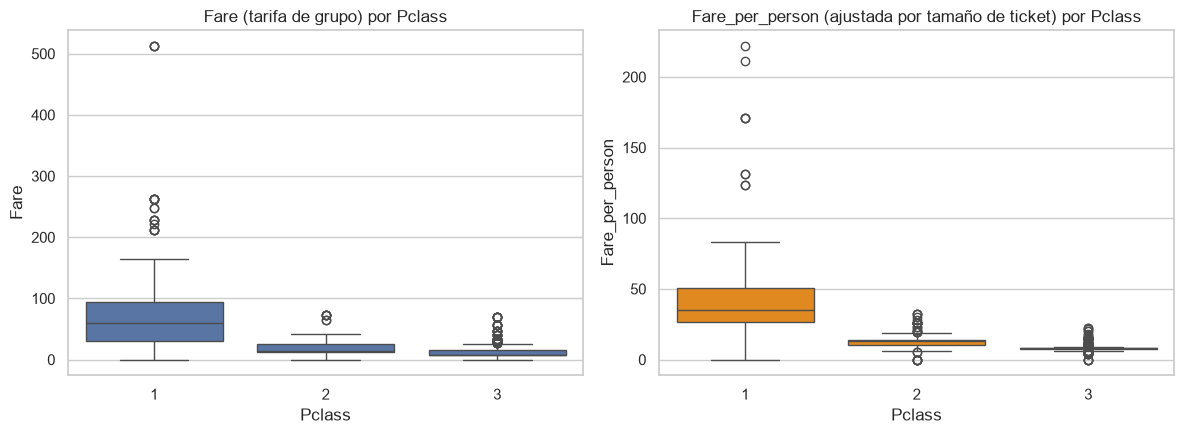

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="Pclass", y="Fare", ax=axes[0])
axes[0].set_title("Fare (tarifa de grupo) por Pclass")

sns.boxplot(data=df, x="Pclass", y="Fare_per_person", ax=axes[1], color="darkorange")
axes[1].set_title("Fare_per_person (ajustada por tamaño de ticket) por Pclass")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_fare_per_person.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
g0 = df.loc[df.Survived == 0, "Fare_per_person"]
g1 = df.loc[df.Survived == 1, "Fare_per_person"]
u, p = stats.mannwhitneyu(g0, g1)
n0, n1 = len(g0), len(g1)
r_biserial = 1 - (2 * u) / (n0 * n1)

print(f"Mann-Whitney U — Fare_per_person ~ Survived: U={u:.1f}  p={p:.3e}  r_rango_biserial={r_biserial:.3f}")
print(f"Mediana Fare_per_person — no sobrevivió: {g0.median():.2f} | sobrevivió: {g1.median():.2f}")
print("\nPara referencia, Fase 2-3 reportó para Fare_log: U=57806.5, p=4.55e-22, r=0.384 (mismo orden de magnitud).")

Mann-Whitney U — Fare_per_person ~ Survived: U=58829.5  p=6.292e-21  r_rango_biserial=0.373
Mediana Fare_per_person — no sobrevivió: 8.05 | sobrevivió: 13.00

Para referencia, Fase 2-3 reportó para Fare_log: U=57806.5, p=4.55e-22, r=0.384 (mismo orden de magnitud).


El 32.3 % de los pasajeros tiene un `TicketGroupSize` distinto de su `FamilySize`: confirma que ambas variables capturan conceptos relacionados pero no idénticos (grupo de viaje por boleto vs. núcleo familiar declarado), por lo que no es redundante mantener las dos como candidatas (se decide su destino final con evidencia, en la sección VI). `Fare_per_person` reduce apenas la asimetría de `Fare` (de 4.78 a 4.37); es la transformación `log1p` la que la corrige (0.33 para `Fare_per_person_log`, en línea con el 0.39 ya observado para `Fare_log`). Además, `Fare_per_person` mantiene una asociación con `Survived` del mismo orden que `Fare_log` (r ≈ 0.37-0.38 en ambos casos), pero con una lectura más limpia: aísla la tarifa pagada **por persona** del efecto de "viajar en grupo grande", que ya se representa por separado con `FamilySize`/`TicketGroupSize`.

### V.2 `Sex_Pclass`: interacción explícita entre sexo y clase

**Hallazgo que la motiva:** Fase 2-3 (apartado VIII.3, gráfico de interacción) mostró que el efecto de `Pclass` sobre la supervivencia **no es uniforme entre sexos**: la supervivencia femenina es muy alta en 1ª y 2ª clase (96.8 % y 92.1 %) y cae con fuerza solo en 3ª (50.0 %), mientras que la masculina ya es baja en 1ª clase (36.9 %) y se hunde desde la 2ª (15.7 % y 13.5 % en 2ª y 3ª). Una variable categórica que combine ambas dimensiones puede capturar esa interacción de forma explícita, en vez de dejar que un modelo lineal la infiera solo a partir de dos variables por separado (que asumen efectos aditivos).

**Construcción:** concatenación de `Sex` y `Pclass` en una única variable categórica de 6 niveles.

In [8]:
df["Sex_Pclass"] = df["Sex"].astype(str) + "_" + df["Pclass"].astype(str)

tabla_supervivencia = df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean").round(3)
print("Tasa de supervivencia por Sex x Pclass:")
print(tabla_supervivencia)


def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, p, _, esperadas = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
    return chi2, p, v


resultados_v = []
for nombre, serie in [("Sex", df["Sex"]), ("Pclass", df["Pclass"]), ("Sex_Pclass", df["Sex_Pclass"])]:
    chi2, p, v = cramers_v(serie, df["Survived"])
    resultados_v.append({"variable": nombre, "chi2": round(chi2, 2), "p_valor": p, "cramers_v": round(v, 3)})

tabla_v = pd.DataFrame(resultados_v)
tabla_v

Tasa de supervivencia por Sex x Pclass:
Pclass      1      2      3
Sex                        
female  0.968  0.921  0.500
male    0.369  0.157  0.135


,variable,chi2,p_valor,cramers_v
0,Sex,260.72,1.197357e-58,0.541
1,Pclass,102.89,4.549252e-23,0.340
2,Sex_Pclass,350.68,1.252307e-73,0.627


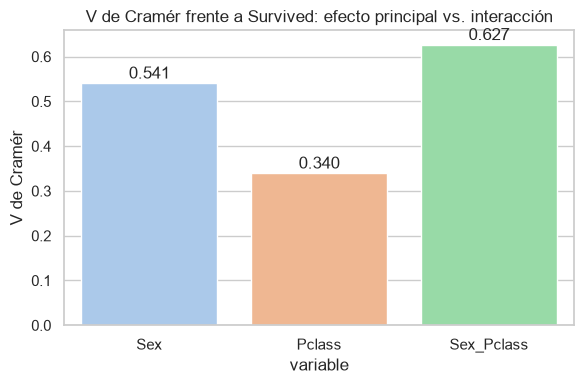

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=tabla_v, x="variable", y="cramers_v", hue="variable", palette="pastel", legend=False, ax=ax)
ax.set_title("V de Cramér frente a Survived: efecto principal vs. interacción")
ax.set_ylabel("V de Cramér")
for i, valor in enumerate(tabla_v["cramers_v"]):
    ax.text(i, valor + 0.01, f"{valor:.3f}", ha="center")
plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_interaccion_sex_pclass.png", dpi=150, bbox_inches="tight")
plt.show()

`Sex_Pclass` tiene una V de Cramér más alta que cualquiera de sus dos variables de origen por separado. Esto es **consistente** con el hallazgo cualitativo de Fase 2-3, pero no lo demuestra por sí solo: al cruzar dos variables categóricas, la variable resultante conoce estrictamente todo lo que cada una por separado conoce (más las distinciones cruzadas), así que su V de Cramér frente al objetivo tiende a igualar o superar a la de cada marginal **incluso si el efecto real fuera puramente aditivo**, sin ninguna interacción genuina. Para confirmar que hay una interacción real (y no solo "más información por combinar variables"), se compara formalmente un modelo aditivo (`Survived ~ Sex + Pclass`) contra el modelo saturado equivalente al cruce completo, mediante un test de razón de verosimilitudes.

In [10]:
def log_verosimilitud(X, y):
    modelo = LogisticRegression(penalty=None, max_iter=2000)
    modelo.fit(X, y)
    p = np.clip(modelo.predict_proba(X)[:, 1], 1e-12, 1 - 1e-12)
    n_parametros = modelo.coef_.size + 1  # + intercepto
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)), n_parametros


y_obj = df["Survived"].values
X_aditivo = pd.concat(
    [pd.get_dummies(df["Sex"], drop_first=True), pd.get_dummies(df["Pclass"].astype(str), drop_first=True)],
    axis=1,
).values.astype(float)
X_saturado = pd.get_dummies(df["Sex_Pclass"], drop_first=True).values.astype(float)

ll_aditivo, k_aditivo = log_verosimilitud(X_aditivo, y_obj)
ll_saturado, k_saturado = log_verosimilitud(X_saturado, y_obj)

lr_stat = 2 * (ll_saturado - ll_aditivo)
grados_libertad = k_saturado - k_aditivo
p_lr = stats.chi2.sf(lr_stat, grados_libertad)

print(f"Modelo aditivo (Sex + Pclass): log-verosimilitud={ll_aditivo:.2f}, parámetros={k_aditivo}")
print(f"Modelo saturado (Sex x Pclass completo): log-verosimilitud={ll_saturado:.2f}, parámetros={k_saturado}")
print(f"\nTest de razón de verosimilitudes (interacción vs. modelo aditivo):")
print(f"LR = {lr_stat:.2f}   df = {grados_libertad}   p = {p_lr:.2e}")

Modelo aditivo (Sex + Pclass): log-verosimilitud=-413.44, parámetros=4
Modelo saturado (Sex x Pclass completo): log-verosimilitud=-399.05, parámetros=6

Test de razón de verosimilitudes (interacción vs. modelo aditivo):
LR = 28.79   df = 2   p = 5.60e-07


El test de razón de verosimilitudes confirma que la interacción es estadísticamente significativa más allá de lo que explican los efectos aditivos de `Sex` y `Pclass` por separado (p < 0.001), lo cual sí respalda formalmente la decisión de incorporar `Sex_Pclass` como variable derivada.

### V.3 Alerta de *data leakage*

Ninguna de las dos variables derivadas usa `Survived` (ni ninguna variable posterior al hundimiento, como `alive` de la fuente `seaborn`-data, que **no** se incorpora al pipeline por esa misma razón). `Fare_per_person` se construye solo a partir de `Fare` y `Ticket`; `Sex_Pclass`, solo a partir de `Sex` y `Pclass`. Ambas están disponibles, en principio, al momento de la venta del pasaje, por lo que no hay fuga de información hacia el objetivo.

---
## VI. Selección preliminar de características

Se decide, para cada variable candidata, si se **prioriza**, **conserva**, **revisa** o **descarta**, usando cuatro criterios explícitos: (1) relevancia analítica/predictiva respecto de `Survived`, (2) redundancia con otras variables, (3) interpretabilidad, (4) consistencia/robustez de la evidencia. No se entrena ningún modelo predictivo en esta fase: la evidencia de "utilidad para modelamiento" se construye con V de Cramér, correlación de rango-biserial (ya calculadas en Fases 2-3 y en la sección V) y con *mutual information*, una medida no paramétrica de relevancia frente al objetivo.

### VI.1 Redundancia con las columnas heredadas de la integración `seaborn`-data

Fase 2-3 ya había validado que `Pclass` ↔ `class` y `Embarked_clean` ↔ `embark_town` son exactamente la misma información relabeled (correspondencia diagonal perfecta, apartado V.2). Falta verificar lo mismo para `who`, `adult_male` y `alone`, que no se validaron explícitamente en esa fase.

In [11]:
who_reconstruido = np.where(df["Age_clean"] < 16, "child", np.where(df["Sex"] == "male", "man", "woman"))
adult_male_reconstruido = (df["Sex"] == "male") & (df["Age_clean"] >= 16)
alone_reconstruido = df["IsAlone"] == 1

coincidencia = pd.Series({
    "who == f(Sex, Age_clean<16)": (who_reconstruido == df["who"]).mean(),
    "adult_male == f(Sex, Age_clean>=16)": (adult_male_reconstruido.values == df["adult_male"].astype(bool).values).mean(),
    "alone == IsAlone": (alone_reconstruido.values == df["alone"].astype(bool).values).mean(),
}) * 100
coincidencia.round(2)

who == f(Sex, Age_clean<16)            100.0
adult_male == f(Sex, Age_clean>=16)    100.0
alone == IsAlone                       100.0
dtype: float64

Las tres coinciden en el 100 % de los 891 registros con una regla determinística a partir de columnas propias ya existentes (`Sex`, `Age_clean`, `IsAlone`). Sumado a lo ya probado en Fase 2-3 para `class` ↔ `Pclass`, `embark_town` ↔ `Embarked_clean` y `deck` ↔ `Cabin_letra` (100 % de coincidencia en los casos con ambos datos, apartado V.2), **las seis columnas heredadas de la fuente `seaborn`-data (`class`, `who`, `adult_male`, `deck`, `embark_town`, `alone`) se descartan del set final de características**: no aportan información nueva y mantenerlas sería una forma de contar la misma señal dos veces. La información de `deck` sobrevive en `Deck_combinado`, que sí se conserva (sección VI.4).

### VI.2 Redundancia entre variables propias

Se revisan dos redundancias adicionales, no analizadas en Fases 2-3 porque en ese momento no era su objetivo: (a) `Title_agrupado` vs. `Sex_bin`, y (b) el bloque de variables numéricas relacionadas con tarifa y tamaño de grupo (`Fare_log`, `Fare_per_person_log`, `FamilySize`, `TicketGroupSize`).

In [12]:
chi2_ts, p_ts, v_ts = cramers_v(df["Title_agrupado"], df["Sex"])
print(f"Title_agrupado ~ Sex (redundancia ENTRE variables, no con el objetivo): V de Cramér = {v_ts:.3f}  (p={p_ts:.2e})")

Title_agrupado ~ Sex (redundancia ENTRE variables, no con el objetivo): V de Cramér = 0.995  (p=2.55e-188)


In [13]:
variables_continuas = ["Age_clean", "Fare_log", "Fare_per_person_log", "FamilySize", "TicketGroupSize"]
corr_spearman = df[variables_continuas].corr(method="spearman").round(2)
corr_spearman

,Age_clean,Fare_log,Fare_per_person_log,FamilySize,TicketGroupSize
Age_clean,1.00,0.17,0.36,-0.20,-0.15
Fare_log,0.17,1.00,0.75,0.53,0.63
Fare_per_person_log,0.36,0.75,1.00,0.10,0.05
FamilySize,-0.20,0.53,0.10,1.00,0.66
TicketGroupSize,-0.15,0.63,0.05,0.66,1.00


- **`Title_agrupado` vs. `Sex`:** V de Cramér ≈ 0.995 — prácticamente redundantes entre sí. Sin embargo, `Title_agrupado` tiene mayor relevancia frente a `Survived` que `Sex` por separado (V = 0.570 vs. 0.541, Fase 2-3, apartado VIII.1), porque distingue además a los niños (`Master`) del resto de los varones adultos, algo que `Sex` no captura. **Decisión:** se conserva `Title_agrupado` como la variable categórica de sexo/estatus, y se **descarta `Sex_bin`** del set final de características por redundancia (su señal queda subsumida en `Title_agrupado`).
- **Bloque tarifa/grupo:** `Fare_log` y `Fare_per_person_log` correlacionan fuerte entre sí (Spearman alto, ver tabla), y `Fare_log` además correlaciona de forma no trivial con `FamilySize` y `TicketGroupSize`. Esto sugiere *algo* de solapamiento entre "tarifa" y "tamaño de grupo", pero una correlación entre dos predictores no dice por sí sola cuánto de la asociación de uno con `Survived` es atribuible al otro — para eso hace falta una correlación parcial, que se calcula a continuación.
- `FamilySize` y `TicketGroupSize` correlacionan moderadamente entre sí, pero la sección V.1 ya mostró que describen conceptos distintos en el 32.3 % de los casos (núcleo familiar vs. grupo de viaje/boleto) — **se conservan ambas**.

In [14]:
def residualizar(y, X):
    X = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ beta


controles_grupo = df[["FamilySize", "TicketGroupSize"]].values.astype(float)
surv_residual = residualizar(df["Survived"].values.astype(float), controles_grupo)

filas_parcial = []
for nombre in ["Fare_log", "Fare_per_person_log"]:
    r_marginal, p_marginal = stats.spearmanr(df[nombre], df["Survived"])
    x_residual = residualizar(df[nombre].values.astype(float), controles_grupo)
    r_parcial, p_parcial = stats.spearmanr(x_residual, surv_residual)
    filas_parcial.append({
        "variable": nombre, "r_marginal": round(r_marginal, 3),
        "r_parcial_controlando_grupo": round(r_parcial, 3),
        "reduccion_pct": round((1 - r_parcial / r_marginal) * 100, 1),
    })

tabla_parcial = pd.DataFrame(filas_parcial)
tabla_parcial

,variable,r_marginal,r_parcial_controlando_grupo,reduccion_pct
0,Fare_log,0.324,0.289,10.7
1,Fare_per_person_log,0.315,0.278,11.5


La correlación parcial (controlando `FamilySize` y `TicketGroupSize`) baja de forma similar para ambas variables (~11-12 %), no solo para `Fare_log`. Es decir, **la evidencia no muestra que `Fare_per_person_log` esté especialmente libre** del solapamiento con el tamaño del grupo: dividir por el tamaño del ticket no aísla la tarifa individual de ese efecto tanto como parecía sugerir la tabla de correlaciones simples. **La decisión de priorizar `Fare_per_person_log` sobre `Fare_log` se mantiene**, pero se apoya en el argumento de diseño conceptual —aislar la tarifa pagada *por persona* del efecto de "viajar en grupo grande" es, en sí, una representación más interpretable y menos propensa a confundirse con `FamilySize`/`TicketGroupSize` en un modelo posterior—, no en que reduzca de forma diferencial la varianza compartida con el tamaño del grupo, que la evidencia de esta sección no respalda. Por la misma razón (redundancia con `Fare_per_person_log` y con el tamaño del grupo, no por una supuesta mediación exclusiva), se **descartan `Fare_log` y `FareBand`** (su versión discretizada) del set final, dejando `FamilySize` y `TicketGroupSize` como las variables encargadas de representar el tamaño del grupo.

### VI.3 Relevancia: *mutual information* frente a `Survived`

Como evidencia adicional de "utilidad para una etapa posterior de modelamiento" (sin entrenar un modelo), se calcula la información mutua de cada variable candidata (ya sobreviviente de los descartes anteriores, más un par de casos límite) respecto de `Survived`.

In [15]:
candidatas_mi = {
    "Pclass": "cat", "Title_agrupado": "cat", "Sex_Pclass": "cat", "AgeGroup": "cat",
    "Age_clean": "num", "Fare_per_person_log": "num", "FamilySize": "num",
    "TicketGroupSize": "num", "IsAlone": "cat", "Embarked_clean": "cat", "Deck_combinado": "cat",
}

X_mi = pd.DataFrame(index=df.index)
es_discreta = []
for columna, tipo in candidatas_mi.items():
    if tipo == "cat":
        X_mi[columna] = LabelEncoder().fit_transform(df[columna].astype(str))
        es_discreta.append(True)
    else:
        X_mi[columna] = df[columna]
        es_discreta.append(False)

mi = mutual_info_classif(X_mi, df["Survived"], discrete_features=es_discreta, random_state=RANDOM_STATE)
ranking_mi = pd.Series(mi, index=X_mi.columns, name="mutual_information").sort_values(ascending=False).round(3)
ranking_mi

Sex_Pclass             0.218
Title_agrupado         0.169
Fare_per_person_log    0.117
Pclass                 0.058
Deck_combinado         0.055
TicketGroupSize        0.040
Age_clean              0.037
IsAlone                0.021
FamilySize             0.020
Embarked_clean         0.014
AgeGroup               0.009
Name: mutual_information, dtype: float64

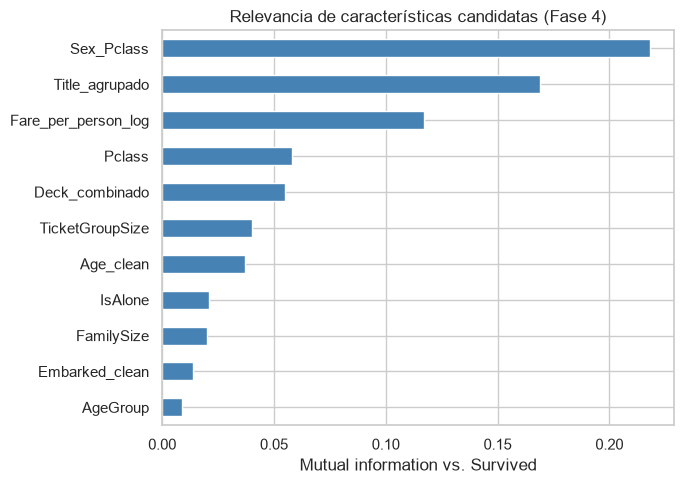

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
ranking_mi.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mutual information vs. Survived")
ax.set_title("Relevancia de características candidatas (Fase 4)")
plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_mutual_information.png", dpi=150, bbox_inches="tight")
plt.show()

`mutual_info_classif` estima la información mutua con un método basado en vecinos más cercanos que, para las variables continuas, agrega ruido aleatorio como parte del cálculo. Antes de leer el ranking como si fuera un número exacto, conviene comprobar qué tan estable es frente a distintas semillas.

In [17]:
comparacion_semillas = pd.DataFrame({
    f"seed_{s}": mutual_info_classif(X_mi, df["Survived"], discrete_features=es_discreta, random_state=s)
    for s in [0, 1, RANDOM_STATE]
}, index=X_mi.columns).round(3)
comparacion_semillas["rango_max_min"] = (comparacion_semillas.max(axis=1) - comparacion_semillas.min(axis=1)).round(3)
comparacion_semillas.sort_values("seed_42", ascending=False)

,seed_0,seed_1,seed_42,rango_max_min
Sex_Pclass,0.218,0.218,0.218,0.000
Title_agrupado,0.169,0.169,0.169,0.000
Fare_per_person_log,0.111,0.096,0.117,0.021
Pclass,0.058,0.058,0.058,0.000
Deck_combinado,0.055,0.055,0.055,0.000
TicketGroupSize,0.037,0.040,0.040,0.003
Age_clean,0.051,0.088,0.037,0.051
IsAlone,0.021,0.021,0.021,0.000
FamilySize,0.058,0.070,0.020,0.050
Embarked_clean,0.014,0.014,0.014,0.000


Tres observaciones, ya con esta verificación de estabilidad:

1. **El extremo superior es estable:** `Sex_Pclass`, `Title_agrupado` y `Fare_per_person_log` quedan siempre en los tres primeros lugares, sin importar la semilla — es la evidencia más confiable del ranking.
2. **El extremo inferior también es estable:** `AgeGroup` y `Embarked_clean` quedan siempre entre las de menor información mutua. Para `AgeGroup` esto contrasta con que su V de Cramér frente a `Survived` fue estadísticamente significativa en Fase 2-3 (V = 0.137, p = 0.002): significancia estadística y relevancia práctica no son lo mismo, y con 891 casos incluso una asociación débil puede resultar significativa. Aun así, se **conserva `AgeGroup`** (no se descarta) porque codifica el patrón "niños primero", de sentido sustantivo bien documentado para este dataset, y no hay una alternativa mejor para capturar ese efecto no lineal de la edad — se documenta explícitamente que su aporte cuantitativo es marginal.
3. **El tramo intermedio mezcla dos situaciones distintas, que conviene no confundir.** `Age_clean` y `FamilySize` sí son inestables en su propio valor (rango entre semillas de 0.051 y 0.050 respectivamente); `TicketGroupSize` es casi estable (rango 0.003). En cambio, `Pclass` y `Deck_combinado` tienen rango **exactamente 0.000**: al ser variables discretas, `mutual_info_classif` no les agrega ruido, así que su valor puntual es perfectamente reproducible — lo único que cambia entre semillas es su *posición relativa* en el ranking, porque las variables vecinas inestables (`Age_clean`, `FamilySize`) se mueven alrededor de ellas. En ningún caso de este tramo intermedio **se usa la cifra puntual de MI para decidir entre variables**. La decisión sobre `IsAlone` frente a `FamilySize`, por ejemplo, no se apoya en cuál tiene mayor *mutual information* (ambas caen en este tramo, con valores bajos y en el caso de `FamilySize` inestables), sino en un argumento estructural más sólido: `IsAlone` es, por construcción, una función determinística de `FamilySize` (`IsAlone = 1` si y solo si `FamilySize == 1`), de modo que no puede aportar información que `FamilySize` no contenga ya (por la desigualdad de procesamiento de datos). **Se descarta `IsAlone`** por esa redundancia estructural (la baja información mutua observada es consistente con esa conclusión, pero no es el argumento principal). Del mismo modo, `Age_clean` (continua, sin discretizar) mostró en Fase 2-3 que no tiene una diferencia significativa con `Survived` (Mann-Whitney, p = 0.25): se descarta como variable numérica independiente, ya que su información relevante (el efecto no lineal en la niñez) queda mejor representada por `AgeGroup`.

### VI.4 Tabla de decisiones final

In [18]:
decisiones = pd.DataFrame([
    {"variable": "Sex_Pclass",          "decision": "Priorizar", "criterio_principal": "Relevancia (V=0.627, MI más alta) — interacción documentada en Fase 2-3"},
    {"variable": "Title_agrupado",      "decision": "Priorizar", "criterio_principal": "Relevancia (V=0.570) y no redundante en info frente a Sex_bin"},
    {"variable": "Pclass",              "decision": "Conservar", "criterio_principal": "Relevancia (V=0.340) e interpretabilidad ordinal directa"},
    {"variable": "Fare_per_person_log", "decision": "Conservar", "criterio_principal": "Aísla tarifa individual del efecto de grupo; reemplaza a Fare_log"},
    {"variable": "FamilySize",          "decision": "Conservar", "criterio_principal": "Relevancia validada en Fase 2-3 (p=7.97e-7); concepto distinto de TicketGroupSize"},
    {"variable": "TicketGroupSize",     "decision": "Conservar", "criterio_principal": "Insumo de Fare_per_person y señal propia (32% distinta de FamilySize)"},
    {"variable": "Embarked_clean",      "decision": "Conservar", "criterio_principal": "Relevancia significativa (V=0.171) y baja redundancia con el resto"},
    {"variable": "AgeGroup",            "decision": "Revisar",   "criterio_principal": "Significativa pero MI marginal; se conserva por interpretabilidad sustantiva"},
    {"variable": "Deck_combinado",      "decision": "Revisar",   "criterio_principal": "Relevancia moderada (V=0.334) pero ~77% de datos imputados como 'Desconocida'"},
    {"variable": "Age_clean",           "decision": "Descartar", "criterio_principal": "Sin diferencia significativa vs. Survived (Mann-Whitney p=0.25)"},
    {"variable": "Sex_bin",             "decision": "Descartar", "criterio_principal": "Redundante con Title_agrupado (V=0.995), que tiene mayor relevancia"},
    {"variable": "Fare_log",            "decision": "Descartar", "criterio_principal": "Redundante con Fare_per_person_log y con el tamaño del grupo"},
    {"variable": "FareBand",            "decision": "Descartar", "criterio_principal": "Versión discretizada de Fare, superada por Fare_per_person_log"},
    {"variable": "IsAlone",             "decision": "Descartar", "criterio_principal": "Función determinística de FamilySize (redundancia estructural, no solo estadística)"},
    {"variable": "class/who/adult_male/deck/embark_town/alone", "decision": "Descartar", "criterio_principal": "100% redundantes con columnas propias (Pclass, Sex, Age_clean, Cabin_letra, Embarked_clean, IsAlone)"},
])
decisiones

,variable,decision,criterio_principal
0,Sex_Pclass,Priorizar,"Relevancia (V=0.627, MI más alta) — interacció..."
1,Title_agrupado,Priorizar,Relevancia (V=0.570) y no redundante en info f...
2,Pclass,Conservar,Relevancia (V=0.340) e interpretabilidad ordin...
3,Fare_per_person_log,Conservar,Aísla tarifa individual del efecto de grupo; r...
4,FamilySize,Conservar,Relevancia validada en Fase 2-3 (p=7.97e-7); c...
5,TicketGroupSize,Conservar,Insumo de Fare_per_person y señal propia (32% ...
6,Embarked_clean,Conservar,Relevancia significativa (V=0.171) y baja redu...
7,AgeGroup,Revisar,Significativa pero MI marginal; se conserva po...
8,Deck_combinado,Revisar,Relevancia moderada (V=0.334) pero ~77% de dat...
9,Age_clean,Descartar,Sin diferencia significativa vs. Survived (Man...


---
## VII. Documentación y trazabilidad del pipeline

Bitácora consolidada de las acciones aplicadas en este notebook, en orden de ejecución, con su efecto verificable en los datos. Cada fila corresponde a una celda de código ya ejecutada arriba; se reconstruye aquí como tabla única para facilitar la trazabilidad, tal como exige la rúbrica (documentación reproducible de decisiones y efectos).

In [19]:
bitacora = pd.DataFrame([
    {"paso": 1, "seccion": "IV", "accion": "Diagnóstico de asimetría residual",
     "variables": "Age_clean, Fare_log, SibSp, Parch, FamilySize",
     "efecto_o_justificacion": "Confirma que solo Fare ya fue tratada; SibSp/Parch ya están resueltas vía FamilySize"},
    {"paso": 2, "seccion": "V.1", "accion": "Creación de TicketGroupSize y Fare_per_person(_log)",
     "variables": "Ticket, Fare -> TicketGroupSize, Fare_per_person, Fare_per_person_log",
     "efecto_o_justificacion": "Asimetría de Fare 4.78 -> 4.37 (Fare_per_person) -> 0.33 (Fare_per_person_log, tras log1p); r rango-biserial=0.373 vs. Survived (p=6.3e-21)"},
    {"paso": 3, "seccion": "V.2", "accion": "Creación de interacción Sex_Pclass",
     "variables": "Sex, Pclass -> Sex_Pclass",
     "efecto_o_justificacion": "V de Cramér sube de 0.541/0.340 (efectos simples) a 0.627 (cruce); interacción confirmada con test de razón de verosimilitudes (p=5.6e-7)"},
    {"paso": 4, "seccion": "VI.1", "accion": "Verificación de redundancia con columnas seaborn-data",
     "variables": "who, adult_male, alone, class, embark_town, deck",
     "efecto_o_justificacion": "100% redundantes -> se descartan del set final"},
    {"paso": 5, "seccion": "VI.2", "accion": "Verificación de redundancia entre variables propias",
     "variables": "Title_agrupado vs Sex_bin; Fare_log vs Fare_per_person_log/FamilySize/TicketGroupSize",
     "efecto_o_justificacion": "V=0.995 (Title~Sex) -> se descarta Sex_bin; correlacion parcial similar en Fare_log/Fare_per_person_log -> Fare_log se descarta por interpretabilidad, no por mediacion diferencial"},
    {"paso": 6, "seccion": "VI.3", "accion": "Cálculo de mutual information (con verificación de estabilidad entre semillas)",
     "variables": "11 variables candidatas vs Survived",
     "efecto_o_justificacion": "Extremos estables (top: Sex_Pclass/Title_agrupado/Fare_per_person_log; bottom: AgeGroup/Embarked_clean); tramo intermedio ruidoso -> decisiones ahí se basan en redundancia estructural, no en el valor puntual de MI"},
    {"paso": 7, "seccion": "VI.4", "accion": "Tabla de decisiones final",
     "variables": "Todas las candidatas",
     "efecto_o_justificacion": "Clasificación explícita: priorizar / conservar / revisar / descartar"},
    {"paso": 8, "seccion": "VIII", "accion": "Codificación y escalado del set final",
     "variables": "Ver sección VIII",
     "efecto_o_justificacion": "One-hot (nominales) + RobustScaler (numéricas continuas); exportación a titanic_features.csv"},
])
bitacora

,paso,seccion,accion,variables,efecto_o_justificacion
0,1,IV,Diagnóstico de asimetría residual,"Age_clean, Fare_log, SibSp, Parch, FamilySize",Confirma que solo Fare ya fue tratada; SibSp/P...
1,2,V.1,Creación de TicketGroupSize y Fare_per_person(...,"Ticket, Fare -> TicketGroupSize, Fare_per_pers...",Asimetría de Fare 4.78 -> 4.37 (Fare_per_perso...
2,3,V.2,Creación de interacción Sex_Pclass,"Sex, Pclass -> Sex_Pclass",V de Cramér sube de 0.541/0.340 (efectos simpl...
3,4,VI.1,Verificación de redundancia con columnas seabo...,"who, adult_male, alone, class, embark_town, deck",100% redundantes -> se descartan del set final
4,5,VI.2,Verificación de redundancia entre variables pr...,Title_agrupado vs Sex_bin; Fare_log vs Fare_pe...,V=0.995 (Title~Sex) -> se descarta Sex_bin; co...
5,6,VI.3,Cálculo de mutual information (con verificació...,11 variables candidatas vs Survived,Extremos estables (top: Sex_Pclass/Title_agrup...
6,7,VI.4,Tabla de decisiones final,Todas las candidatas,Clasificación explícita: priorizar / conservar...
7,8,VIII,Codificación y escalado del set final,Ver sección VIII,One-hot (nominales) + RobustScaler (numéricas ...


**Organización del notebook:** las secciones siguen, en orden, el mismo esquema exigido por las instrucciones de la Fase 4 (encabezado → carga → revisión inicial → transformaciones → variables derivadas → selección → documentación → dataset final → cierre), que a su vez es el mismo esquema que seguirán el informe PDF y la presentación de esta fase (correspondencia 1 a 1 entre los apartados de este notebook y los apartados III-VIII del informe complementario). Las decisiones de la sección VI quedan además consolidadas en la tabla de la sección VI.4 y en la bitácora de esta sección, de modo que el informe pueda remitir directamente a ellas sin repetir el detalle de cada cálculo.

---
## VIII. Resultado final del dataset preparado

Se construye el dataset final de características a partir de la tabla de decisiones (sección VI.4), aplicando:
- **Codificación** *one-hot* (`drop_first=True`, para evitar la trampa de las variables ficticias) sobre las variables nominales priorizadas/conservadas/revisadas: `Title_agrupado`, `Sex_Pclass`, `AgeGroup`, `Embarked_clean`, `Deck_combinado`.
- **Escalado robusto** (`RobustScaler`, justificado en la sección IV.2) sobre las variables numéricas continuas: `Fare_per_person_log`, `FamilySize`, `TicketGroupSize`.
- `Pclass` se mantiene sin escalar: es ordinal, de rango pequeño (1-3) y ya interpretable como "número de clase"; escalarla no aporta y dificulta la lectura directa.
- Se conservan `PassengerId` (identificador, para trazabilidad) y `Survived` (variable objetivo, necesaria para cualquier modelamiento posterior).

In [20]:
columnas_categoricas_finales = ["Title_agrupado", "Sex_Pclass", "AgeGroup", "Embarked_clean", "Deck_combinado"]
columnas_numericas_a_escalar = ["Fare_per_person_log", "FamilySize", "TicketGroupSize"]

dummies = pd.get_dummies(df[columnas_categoricas_finales], drop_first=True)

escalador = RobustScaler()
numericas_escaladas = pd.DataFrame(
    escalador.fit_transform(df[columnas_numericas_a_escalar]),
    columns=[f"{c}_rs" for c in columnas_numericas_a_escalar],
    index=df.index,
)

df_features = pd.concat(
    [df[["PassengerId", "Survived", "Pclass"]], numericas_escaladas, dummies],
    axis=1,
)

print("Dataset preparado (Fases 2-3):", df.shape, "columnas")
print("Dataset de características (Fase 4):", df_features.shape, "columnas")
df_features.head()

Dataset preparado (Fases 2-3): (891, 36) columnas
Dataset de características (Fase 4): (891, 30) columnas


,PassengerId,Survived,Pclass,Fare_per_person_log_rs,FamilySize_rs,TicketGroupSize_rs,Title_agrupado_Miss,Title_agrupado_Mr,Title_agrupado_Mrs,Title_agrupado_Nobleza,Title_agrupado_Oficial_Profesional,Sex_Pclass_female_2,Sex_Pclass_female_3,Sex_Pclass_male_1,Sex_Pclass_male_2,Sex_Pclass_male_3,AgeGroup_Adulto (36-60),AgeGroup_Adulto joven (18-35),AgeGroup_Mayor (60+),AgeGroup_Niño (0-12),Embarked_clean_Q,Embarked_clean_S,Deck_combinado_B,Deck_combinado_C,Deck_combinado_D,Deck_combinado_Desconocida,Deck_combinado_E,Deck_combinado_F,Deck_combinado_G,Deck_combinado_T
0,1,0,3,-0.167452,1.0,0.0,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False
1,2,1,1,1.882864,1.0,0.0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
2,3,1,3,-0.093160,0.0,0.0,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False
3,4,1,1,0.971634,1.0,1.0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False
4,5,0,3,-0.080021,0.0,0.0,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False


In [21]:
stats_originales = df[columnas_numericas_a_escalar].describe().T[["mean", "std", "min", "50%", "max"]].add_prefix("orig_")
stats_escaladas = numericas_escaladas.describe().T[["mean", "std", "min", "50%", "max"]].add_prefix("rs_")
stats_escaladas.index = columnas_numericas_a_escalar  # alinear por variable, quitando el sufijo _rs

comparacion_escalado = pd.concat([stats_originales, stats_escaladas], axis=1).round(2)
comparacion_escalado

,orig_mean,orig_std,orig_min,orig_50%,orig_max,rs_mean,rs_std,rs_min,rs_50%,rs_max
Fare_per_person_log,2.60,0.76,0.0,2.29,5.41,0.30,0.72,-2.16,0.0,2.95
FamilySize,1.90,1.61,1.0,1.00,11.00,0.90,1.61,0.00,0.0,10.00
TicketGroupSize,1.79,1.36,1.0,1.00,7.00,0.79,1.36,0.00,0.0,6.00


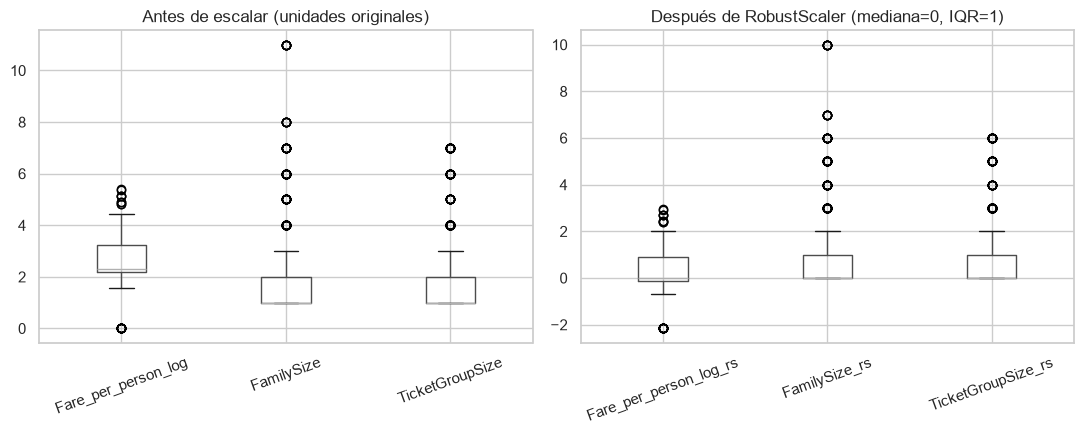

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df[columnas_numericas_a_escalar].boxplot(ax=axes[0])
axes[0].set_title("Antes de escalar (unidades originales)")
axes[0].tick_params(axis="x", rotation=20)

numericas_escaladas.boxplot(ax=axes[1])
axes[1].set_title("Después de RobustScaler (mediana=0, IQR=1)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f4_titanic_escalado_robusto.png", dpi=150, bbox_inches="tight")
plt.show()

El escalado deja las tres variables centradas en 0 (mediana) con un rango intercuartílico de 1, sin necesidad de recortar ni eliminar los valores extremos de `Fare_per_person_log`/`TicketGroupSize` que Fase 2-3 ya había determinado que eran comportamiento legítimo (grupos numerosos, tarifas compartidas) y no errores de dato.

**Mejoras logradas respecto del dataset de entrada de esta fase (`titanic_prepared.csv`):**
- Se resolvió la redundancia entre 6 columnas heredadas de la integración con `seaborn`-data y 5 columnas propias adicionales descartadas en la sección VI (`Age_clean`, `Sex_bin`, `Fare_log`, `FareBand`, `IsAlone`), eliminando duplicación de señal.
- Se incorporaron 2 variables derivadas nuevas con valor analítico verificado (`Fare_per_person_log`, `Sex_Pclass`), cada una con mayor relevancia cuantitativa que sus insumos por separado.
- El set final queda codificado y escalado, listo para alimentar directamente un modelo de clasificación sin transformaciones adicionales.

In [23]:
df_features.to_csv(RUTA_SALIDA, index=False)
print(f"Dataset de características exportado a {RUTA_SALIDA}")
print("Columnas finales:", list(df_features.columns))

Dataset de características exportado a ../data/titanic_features.csv
Columnas finales: ['PassengerId', 'Survived', 'Pclass', 'Fare_per_person_log_rs', 'FamilySize_rs', 'TicketGroupSize_rs', 'Title_agrupado_Miss', 'Title_agrupado_Mr', 'Title_agrupado_Mrs', 'Title_agrupado_Nobleza', 'Title_agrupado_Oficial_Profesional', 'Sex_Pclass_female_2', 'Sex_Pclass_female_3', 'Sex_Pclass_male_1', 'Sex_Pclass_male_2', 'Sex_Pclass_male_3', 'AgeGroup_Adulto (36-60)', 'AgeGroup_Adulto joven (18-35)', 'AgeGroup_Mayor (60+)', 'AgeGroup_Niño (0-12)', 'Embarked_clean_Q', 'Embarked_clean_S', 'Deck_combinado_B', 'Deck_combinado_C', 'Deck_combinado_D', 'Deck_combinado_Desconocida', 'Deck_combinado_E', 'Deck_combinado_F', 'Deck_combinado_G', 'Deck_combinado_T']


---
## IX. Supuestos, limitaciones y cierre del notebook

**Resumen del pipeline implementado:** partiendo de `titanic_prepared.csv` (Fases 2-3), se diagnosticó qué transformación de escala faltaba (`RobustScaler`, justificado por los outliers legítimos de `Fare` ya documentados), se crearon dos variables derivadas motivadas por hallazgos concretos (`Fare_per_person_log`, a partir de la evidencia de tarifas compartidas por `Ticket`; `Sex_Pclass`, a partir de la interacción sexo-clase ya observada), se resolvió explícitamente la redundancia entre columnas propias y heredadas de la integración con `seaborn`-data, se clasificaron todas las variables candidatas en cuatro categorías de decisión con criterios y evidencia cuantitativa (V de Cramér, correlación de rango-biserial, *mutual information*), y se exportó un dataset final codificado y escalado (`titanic_features.csv`).

**Supuestos asumidos:**
- Se asume que los 15 registros con `Fare` = 0 (todos varones, con `Ticket` `LINE` o numeración cercana entre sí) son un valor legítimo del dominio —posiblemente personal de la naviera u otro pasaje sin costo, hipótesis plausible mencionada en análisis públicos del dataset pero que este notebook no puede confirmar con la información disponible— y no un dato faltante mal codificado; por eso se conserva sin imputar (ya lo hereda `Fare_per_person`).
- Se asume que el criterio de selección aplicado (relevancia + redundancia + interpretabilidad + evidencia no paramétrica) es suficiente para una selección *preliminar*; una selección definitiva debería re-evaluarse con el desempeño real de un modelo entrenado, lo cual queda fuera del alcance de esta fase.
- Se asume que la codificación *one-hot* de variables con muchas categorías (`Deck_combinado`, 9 niveles) es adecuada a esta escala de datos (891 filas); en un dataset mucho más grande convendría revisar alternativas (p. ej. *target encoding*) para no inflar excesivamente la dimensionalidad.

**Limitaciones detectadas:**
- `Deck_combinado` sigue teniendo un nivel dominante de datos "Desconocida" (~77 % del total, heredado de Fases 2-3), lo que le resta robustez como predictor aunque se conserve.
- La evidencia de relevancia usada en esta fase (V de Cramér, rango-biserial, *mutual information*) es univariada: no descarta interacciones o efectos condicionales adicionales a `Sex_Pclass` que solo aparecerían al entrenar un modelo real.
- El `RobustScaler` (y la codificación *one-hot*) se ajustaron sobre los 891 registros, sin partición previa entrenamiento/prueba. Para esta fase exploratoria es aceptable, pero al modelar deberán ajustarse solo con los datos de entrenamiento (p. ej. dentro de un `Pipeline` con validación cruzada), o las estadísticas de mediana e IQR de la muestra completa filtrarán información de los datos de prueba.
- El tamaño de muestra (891 registros) limita la robustez de los conteos por celda en variables con más categorías (p. ej. `Sex_Pclass` x `Deck_combinado`), por lo que decisiones basadas en subgrupos muy pequeños deben tomarse con cautela.

**Observación final:** el dataset `titanic_features.csv` resultante queda en condiciones de alimentar directamente una etapa de modelamiento predictivo (clasificación binaria de `Survived`), con un número acotado de características, cada una justificada individualmente, sin variables redundantes conocidas y sin fuga de información hacia el objetivo en la construcción de las variables (ver, no obstante, la última limitación sobre el ajuste del escalador).